# 09 · Preliminary functional-only analysis (NIAK release)

**Status: exploratory.** The protocol is not locked and the structural data are still pending, so nothing here is a confirmatory result. It is recorded in protocol §13.

What this notebook does:
1. builds the design matrix from the features extracted in notebook 03b;
2. runs the **functional** model and the **confounds-only** baseline through the full nested cross-validation (10 repeats × 5 outer folds × 5 inner folds), exactly as the protocol specifies;
3. tests both against chance by label permutation;
4. reports prediction stability;
5. repeats the analysis under the more permissive motion rule as a sensitivity check.

**What it cannot answer:** the primary hypothesis. MKL needs structural features, which arrive with the T1 scans.

**Why the confounds-only baseline matters here.** Patients moved more, so more of their data was scrubbed. If age, sex and mean FD alone separate the groups about as well as connectivity does, the imaging result cannot be read as evidence about brain connectivity.

In [1]:
from pathlib import Path
from functools import partial
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NOTEBOOKS = ROOT / "notebooks"
RESULTS = ROOT / "results"


def use_notebook(name):
    """Run the definition cells (tagged "library") of another notebook in this namespace."""
    notebook = json.loads((NOTEBOOKS / name).read_text(encoding="utf-8"))
    for cell in notebook["cells"]:
        if cell["cell_type"] == "code" and "library" in cell["metadata"].get("tags", []):
            exec("".join(cell["source"]), globals())


def load_yaml(path):
    with open(path, encoding="utf-8") as fh:
        return yaml.safe_load(fh)

In [2]:
use_notebook("07_stability_and_confounds.ipynb")   # stability + metrics + nested CV + models (notebooks 04-06)

In [3]:
def load_niak_design(min_seconds=None, confound_columns=("age", "sex_male", "mean_fd")):
    """Design matrix for the functional arm: column blocks functional | confounds.

    ``min_seconds`` is the retained-scan-time rule; None uses the configured primary rule.
    No imputation: any missing value is an error (protocol §2.5).
    """
    cfg = load_yaml(ROOT / "configs" / "data_config.yaml")
    manifest = pd.read_csv(ROOT / "data" / "participants_manifest_niak.csv", dtype={"participant_id": str})
    if min_seconds is None:
        min_seconds = cfg["niak"]["qc"]["min_retained_seconds"]
    manifest = manifest[manifest["retained_seconds"] >= min_seconds]
    features = pd.read_csv(ROOT / cfg["features_dir"] / "functional_features_niak.csv",
                           dtype={"participant_id": str})
    design = manifest.merge(features, on="participant_id", how="left", validate="one_to_one")
    feature_columns = [c for c in features.columns if c != "participant_id"]
    X = design[feature_columns + list(confound_columns)].to_numpy(float)
    if np.isnan(X).any():
        raise ValueError("Missing values in the design matrix (no imputation allowed).")
    blocks = {"functional": np.arange(len(feature_columns)),
              "confounds": np.arange(len(feature_columns), len(feature_columns) + len(confound_columns))}
    return X, design["label"].to_numpy(int), design["participant_id"].to_numpy(), blocks, design

## The analysis sample
The primary rule keeps participants with at least 180 s of scan time after NIAK's scrubbing.

In [4]:
model_cfg = load_yaml(ROOT / "configs" / "model_config.yaml")
cv_cfg = load_yaml(ROOT / "configs" / "cv_config.yaml")
seeds = read_seeds(ROOT / cv_cfg["seeds_file"])
MODELS = ["functional", "confounds_only"]

X, y, ids, blocks, design = load_niak_design()
print(f"{len(y)} participants: {int(y.sum())} patients, {int((y == 0).sum())} controls")
print(f"features: {len(blocks['functional'])} connectivity edges + {len(blocks['confounds'])} confounds")
print(f"C grid: {model_cfg['svm']['C_grid']} | {cv_cfg['outer']['n_repeats']} repeats x "
      f"{cv_cfg['outer']['n_splits']} outer folds x {cv_cfg['inner']['n_splits']} inner folds")
display(design.groupby("label")[["age", "sex_male", "mean_fd", "retained_seconds"]].mean().round(3))

82 participants: 31 patients, 51 controls
features: 4950 connectivity edges + 3 confounds
C grid: [0.001, 0.01, 0.1, 1.0, 10.0, 100.0] | 10 repeats x 5 outer folds x 5 inner folds


,age,sex_male,mean_fd,retained_seconds
label,,,,
0,32.784,0.686,0.203,264.745
1,33.161,0.839,0.209,248.452


## Run the nested cross-validation
Every data-dependent step (standardization, kernel normalization, C selection, threshold) happens inside the training folds, and both models see identical splits.

In [5]:
import time

start = time.perf_counter()
predictions, selections, weights = run_nested_cv(
    X, y, ids, partial(build_models, model_cfg, blocks, include=MODELS), seeds,
    cv_cfg["outer"]["n_splits"], cv_cfg["inner"]["n_splits"], n_jobs=-1, collect_weights=True)
folds = fold_metrics(predictions)
print(f"done in {time.perf_counter() - start:.0f} s")
display(summarize(folds).round(3))

done in 20 s


,model,auc_mean,auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,balanced_accuracy_std,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std,prevalence_mean,prevalence_std
0,functional,0.688,0.132,0.655,0.142,0.598,0.094,0.616,0.245,0.579,0.235,0.378,0.019
1,confounds_only,0.487,0.155,0.461,0.122,0.490,0.100,0.499,0.388,0.481,0.348,0.378,0.019


## Is connectivity better than the confounds alone?
The paired difference uses the same outer folds for both models, with the Nadeau–Bengio corrected interval (notebook 06). This comparison is **exploratory**: the protocol's primary comparison is MKL versus functional.

mean ΔAUC (functional − confounds-only) = +0.201, corrected 95% CI [-0.010, +0.412], p = 0.061


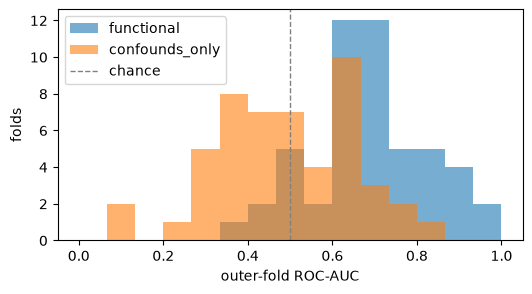

In [6]:
difference = paired_differences(folds, "functional", "confounds_only")
ci = corrected_resampled_ci(difference, test_train_ratio=1 / (cv_cfg["outer"]["n_splits"] - 1))
print(f"mean ΔAUC (functional − confounds-only) = {ci['mean']:+.3f}, "
      f"corrected 95% CI [{ci['ci_low']:+.3f}, {ci['ci_high']:+.3f}], p = {ci['p_two_sided']:.3f}")

fig, ax = plt.subplots(figsize=(6, 3))
for model in MODELS:
    ax.hist(folds.loc[folds["model"] == model, "auc"], bins=15, range=(0, 1), alpha=0.6, label=model)
ax.axvline(0.5, color="grey", ls="--", lw=1, label="chance")
ax.set(xlabel="outer-fold ROC-AUC", ylabel="folds")
ax.legend()
plt.show()

## Does either model beat chance?
Diagnosis labels are permuted and the **complete** nested pipeline is rerun each time, so the null reflects the whole procedure, including hyperparameter selection. The p-value uses the plus-one correction.

This uses fewer permutations than the protocol's 1,000 because the run is exploratory; the smallest p-value it can produce is printed alongside.

500 permutations in 641 s


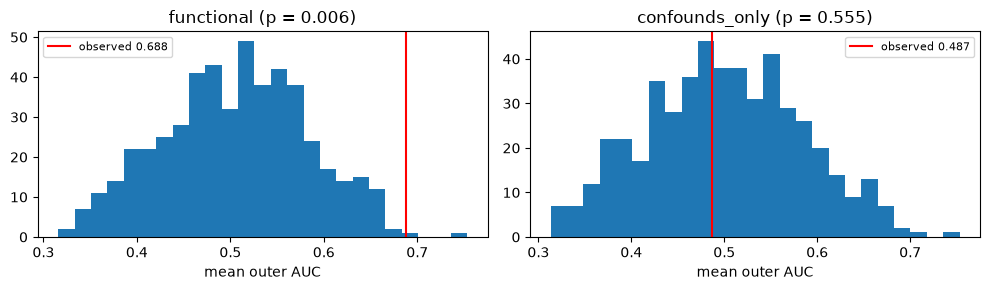

,model,mean_auc,p_permutation,smallest_possible_p
0,functional,0.688,0.005988,0.002
1,confounds_only,0.487,0.554890,0.002


In [7]:
B = 500
start = time.perf_counter()
label_null = run_permutations(
    X, y, ids, partial(build_models, model_cfg, blocks, include=MODELS), seeds,
    mean_auc_by_model, "labels", range(B), cv_cfg["permutation"]["seed"],
    n_outer=cv_cfg["outer"]["n_splits"], n_inner=cv_cfg["inner"]["n_splits"], n_jobs=-1)
print(f"{B} permutations in {time.perf_counter() - start:.0f} s")

observed = mean_auc_by_model(predictions)
fig, axes = plt.subplots(1, len(MODELS), figsize=(10, 3))
rows = []
for ax, model in zip(axes, MODELS):
    p = permutation_p_value(observed[model], label_null[model])
    rows.append({"model": model, "mean_auc": round(observed[model], 3), "p_permutation": p,
                 "smallest_possible_p": round(1 / (B + 1), 4)})
    ax.hist(label_null[model], bins=25)
    ax.axvline(observed[model], color="red", label=f"observed {observed[model]:.3f}")
    ax.set(title=f"{model} (p = {p:.3f})", xlabel="mean outer AUC")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
display(pd.DataFrame(rows))

## Prediction stability
Each participant is tested once per repeat, so each has 10 out-of-sample scores. The spread shows how much a participant's prediction depends on who else was in the training set.

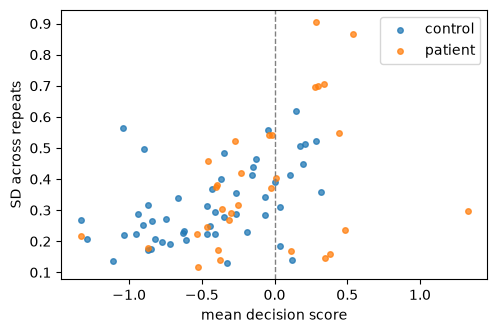

median SD of the decision score: 0.30
participants classified the same way in every repeat: 21 / 82


In [8]:
stability = prediction_stability(predictions, "functional")
fig, ax = plt.subplots(figsize=(5.5, 3.5))
for label, name in [(0, "control"), (1, "patient")]:
    subset = stability[stability["y_true"] == label]
    ax.scatter(subset["mean_score"], subset["sd_score"], s=16, alpha=0.75, label=name)
ax.axvline(0, color="grey", ls="--", lw=1)
ax.set(xlabel="mean decision score", ylabel="SD across repeats")
ax.legend()
plt.show()
print(f"median SD of the decision score: {stability['sd_score'].median():.2f}")
print(f"participants classified the same way in every repeat: "
      f"{int(stability['frac_predicted_patient'].isin([0, 1]).sum())} / {len(stability)}")

## Sensitivity analysis: the more permissive motion rule
NIAK's own criterion keeps participants with at least 120 s of usable data, which is a larger but noisier sample. If the conclusion changes between the two rules, the result depends on that choice.

In [9]:
X2, y2, ids2, blocks2, _ = load_niak_design(min_seconds=cv_cfg and load_yaml(ROOT / "configs" / "data_config.yaml")["niak"]["qc"]["sensitivity_seconds"])
print(f"{len(y2)} participants: {int(y2.sum())} patients, {int((y2 == 0).sum())} controls")
predictions2, _, _ = run_nested_cv(
    X2, y2, ids2, partial(build_models, model_cfg, blocks2, include=MODELS), seeds,
    cv_cfg["outer"]["n_splits"], cv_cfg["inner"]["n_splits"], n_jobs=-1)
display(summarize(fold_metrics(predictions2)).round(3))

101 participants: 43 patients, 58 controls


,model,auc_mean,auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,balanced_accuracy_std,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std,prevalence_mean,prevalence_std
0,functional,0.752,0.112,0.745,0.111,0.665,0.096,0.631,0.197,0.698,0.215,0.426,0.023
1,confounds_only,0.600,0.123,0.586,0.118,0.540,0.069,0.540,0.340,0.539,0.332,0.426,0.023


## Save the results
Everything is written with the tag `niak_functional`, so it never overwrites the confirmatory results.

In [10]:
(RESULTS / "predictions").mkdir(parents=True, exist_ok=True)
(RESULTS / "metrics").mkdir(parents=True, exist_ok=True)
predictions.to_csv(RESULTS / "predictions" / "predictions_niak_functional.csv", index=False)
selections.to_csv(RESULTS / "metrics" / "selections_niak_functional.csv", index=False)
folds.to_csv(RESULTS / "metrics" / "fold_metrics_niak_functional.csv", index=False)
summarize(folds).to_csv(RESULTS / "metrics" / "summary_niak_functional.csv", index=False)
label_null.to_csv(RESULTS / "metrics" / "label_null_niak_functional.csv", index=False)
stability.to_csv(RESULTS / "metrics" / "stability_niak_functional.csv", index=False)
print("saved:", *(p.name for p in sorted((RESULTS / "metrics").glob("*niak_functional*"))), sep="\n  ")

saved:
  fold_metrics_niak_functional.csv
  label_null_niak_functional.csv
  selections_niak_functional.csv
  stability_niak_functional.csv
  summary_niak_functional.csv


## How to read these numbers
- **Exploratory.** The protocol is not locked, so these results cannot be reported as confirmatory. They do show that the pipeline runs end to end on real COBRE data.
- **Small sample.** With roughly 30–50 patients, outer folds hold only a handful of people, so fold-level AUCs vary widely and the corrected intervals are wide.
- **Motion is the rival explanation.** Compare the functional model with the confounds-only baseline before concluding anything about connectivity.
- **Not a clinical claim.** Performance here describes unseen COBRE participants under this design, not patients at another hospital or scanner.